# 🧹 Data Cleaning

## E-Commerce Sales Analytics Dashboard

### Objective

Data cleaning is one of the most important steps in the data analytics workflow.

The purpose of this notebook is to prepare the raw dataset for SQL analysis, exploratory data analysis (EDA), and Power BI dashboard development.

---

## Data Cleaning Tasks

- Load the raw dataset
- Check dataset dimensions
- Standardize column names
- Check missing values
- Check duplicate records
- Verify data types
- Detect outliers
- Save the cleaned dataset

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

# Display all columns
pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")

Libraries imported successfully.


## Load Raw Dataset

Loading the original dataset from the **data/raw** directory.

In [2]:
# Load dataset

df = pd.read_csv("../data/raw/superstore.csv")

# Preview the dataset
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


## Dataset Overview

Checking the dataset dimensions before cleaning.

In [3]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 9994
Columns: 13


## Standardize Column Names

Converting column names into lowercase snake_case format for better readability and consistency.

In [4]:
# Standardize column names

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("-", "_")
)

df.columns

Index(['ship_mode', 'segment', 'country', 'city', 'state', 'postal_code',
       'region', 'category', 'sub_category', 'sales', 'quantity', 'discount',
       'profit'],
      dtype='str')

## Check Missing Values

Missing values can affect analysis accuracy.

Let's identify whether the dataset contains any null values.

In [5]:
df.isnull().sum()

ship_mode       0
segment         0
country         0
city            0
state           0
postal_code     0
region          0
category        0
sub_category    0
sales           0
quantity        0
discount        0
profit          0
dtype: int64

## Check Duplicate Records

Duplicate records may lead to incorrect business insights.

Checking the dataset for duplicate rows.

In [6]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 17


## Remove Duplicate Records

If duplicate records exist, they will be removed.

In [7]:
df = df.drop_duplicates()

print("Updated Shape:", df.shape)

Updated Shape: (9977, 13)


## Verify Data Types

Checking whether each column has the correct data type.

In [8]:
df.info()

<class 'pandas.DataFrame'>
Index: 9977 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ship_mode     9977 non-null   str    
 1   segment       9977 non-null   str    
 2   country       9977 non-null   str    
 3   city          9977 non-null   str    
 4   state         9977 non-null   str    
 5   postal_code   9977 non-null   int64  
 6   region        9977 non-null   str    
 7   category      9977 non-null   str    
 8   sub_category  9977 non-null   str    
 9   sales         9977 non-null   float64
 10  quantity      9977 non-null   int64  
 11  discount      9977 non-null   float64
 12  profit        9977 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 1.1 MB


## Statistical Summary

Generating descriptive statistics to understand numerical features.

In [9]:
df.describe()

,postal_code,sales,quantity,discount,profit
count,9977.000000,9977.000000,9977.000000,9977.000000,9977.00000
mean,55154.964117,230.148902,3.790719,0.156278,28.69013
std,32058.266816,623.721409,2.226657,0.206455,234.45784
min,1040.000000,0.444000,1.000000,0.000000,-6599.97800
25%,23223.000000,17.300000,2.000000,0.000000,1.72620
50%,55901.000000,54.816000,3.000000,0.200000,8.67100
75%,90008.000000,209.970000,5.000000,0.200000,29.37200
max,99301.000000,22638.480000,14.000000,0.800000,8399.97600


## Detect Outliers

Visualizing numerical features using boxplots to identify potential outliers.

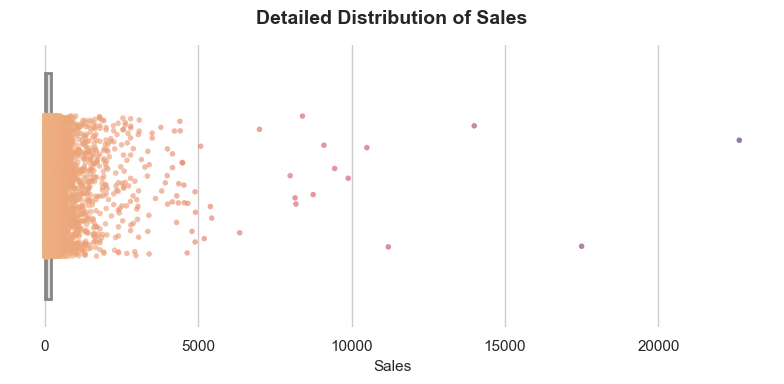

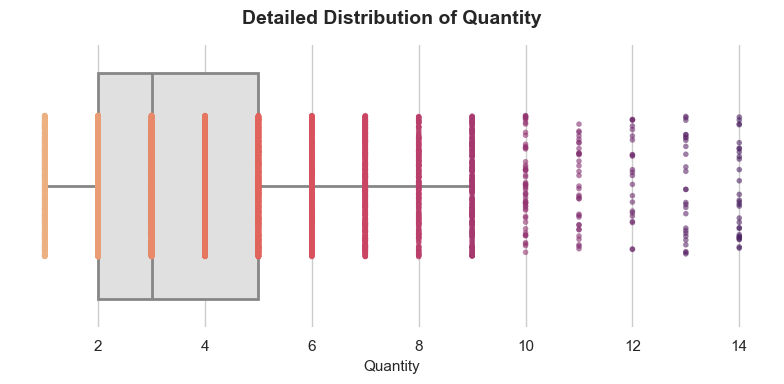

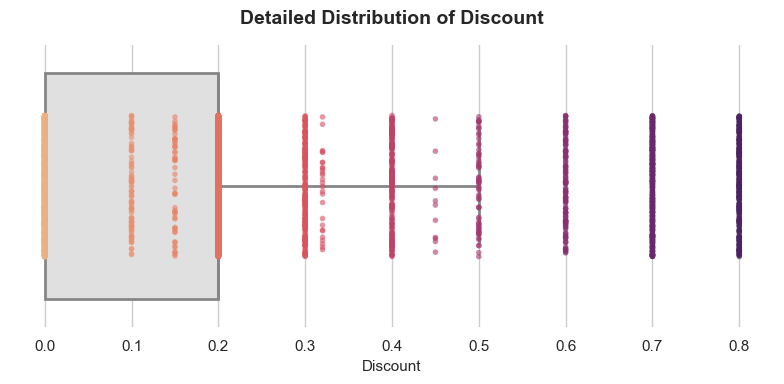

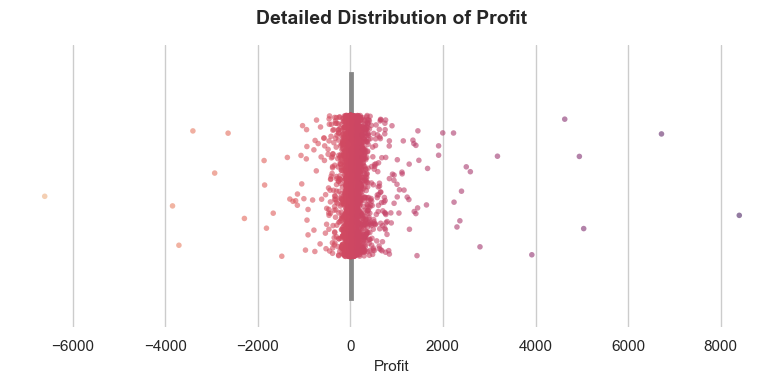

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# সুন্দর ক্লিন থিম
sns.set_theme(style="whitegrid")

numeric_columns = ['sales', 'quantity', 'discount', 'profit']

for col in numeric_columns:
    # missing value বাদ দেওয়া
    clean_data = df[col].dropna()
    
    fig, ax = plt.subplots(figsize=(8, 4))
    
    # ১. পেছনের সুন্দর বক্সপ্লট
    sns.boxplot(
        x=clean_data, 
        orient='h', 
        color="#e0e0e0",     # হালকা ধূসর রঙ
        linewidth=2,
        fliersize=0,         # ডুপ্লিকেট বিন্দু এড়াতে ০
        ax=ax
    )
    
    # ২. ওপরের ইন্ডিভিজুয়াল ডেটা পয়েন্ট (ওয়ার্নিং ফিক্সড)
    sns.stripplot(
        x=clean_data, 
        orient='h',              
        hue=clean_data,      # ওয়ার্নিং বন্ধ করার জন্য hue যোগ করা হয়েছে
        palette="flare",     
        size=4,              
        jitter=0.25,         
        alpha=0.6,           
        legend=False,        # এক্সট্রা লিজেন্ড বক্স হাইড করার জন্য
        ax=ax
    )
    
    # টাইটেল ও এক্স-অক্ষ সাজানো
    ax.set_title(f"Detailed Distribution of {col.capitalize()}", fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel(col.capitalize(), fontsize=11)
    
    # বর্ডার রিমুভ করা
    sns.despine(left=True, bottom=True)
    
    plt.tight_layout()
    plt.show()


## Save Cleaned Dataset

Saving the cleaned dataset for SQL analysis and Power BI dashboard development.

In [11]:
df.to_csv("../data/cleaned/cleaned_superstore.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


# ✅ Summary

## Tasks Completed

- Loaded the raw dataset
- Standardized column names
- Checked missing values
- Checked duplicate records
- Verified data types
- Explored numerical statistics
- Detected potential outliers
- Saved the cleaned dataset

---

## Output

The cleaned dataset has been successfully saved and is ready for:

- SQL Analysis
- Exploratory Data Analysis (EDA)
- Power BI Dashboard Development

**Status:** Data Cleaning Completed ✅